# Fuzzy System - Air Conditioning

We're going to implement a fuzzy system on the air conditioner.

The purpose of the work: to gain skills in building fuzzy systems.

## Library preparation

In [ ]:
! pip install -U scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 11.1 MB/s eta 0:00:00


## Step 1. Define the input and output linguistic variables (the total number of linguistic variables must be at least 3).

**Input**:

* `deltaT = 𝑇_current − T_target` [°C] with domain `0..15 `(Temperature deviation )
* `volume` [m³] with domain `20..120` (Room volume)

* `power`  [kW] with domain `1.0..5.0` (air conditioning capacity)


**Output**: `cooling` [%], domain `0..100` (cooling level / running level)

## Step 2. Set membership functions for fuzzy subsets defined on the values of selected linguistic variables (at least three values for each linguistic variable)

Each subset will be divided into 3 types of linguistic variables likes `small/medium/large`. We will choose `trapmf-trimf-trapmf` for these variables because:

* The two outer edges (`small, high`) use `trapmf` to have a saturated area (`μ = 1`) at the top of the value domain, making the reasoning system stable and sure when the input is very small or very large.

* The middle set (`medium`) uses `trimf` to represent average with clear vertices, singular parameters, easy to calibrate.

* This structure creates a reasonable overlap between fuzzy subsets, ensuring domain covering and smooth control transfers (no sudden jumps).

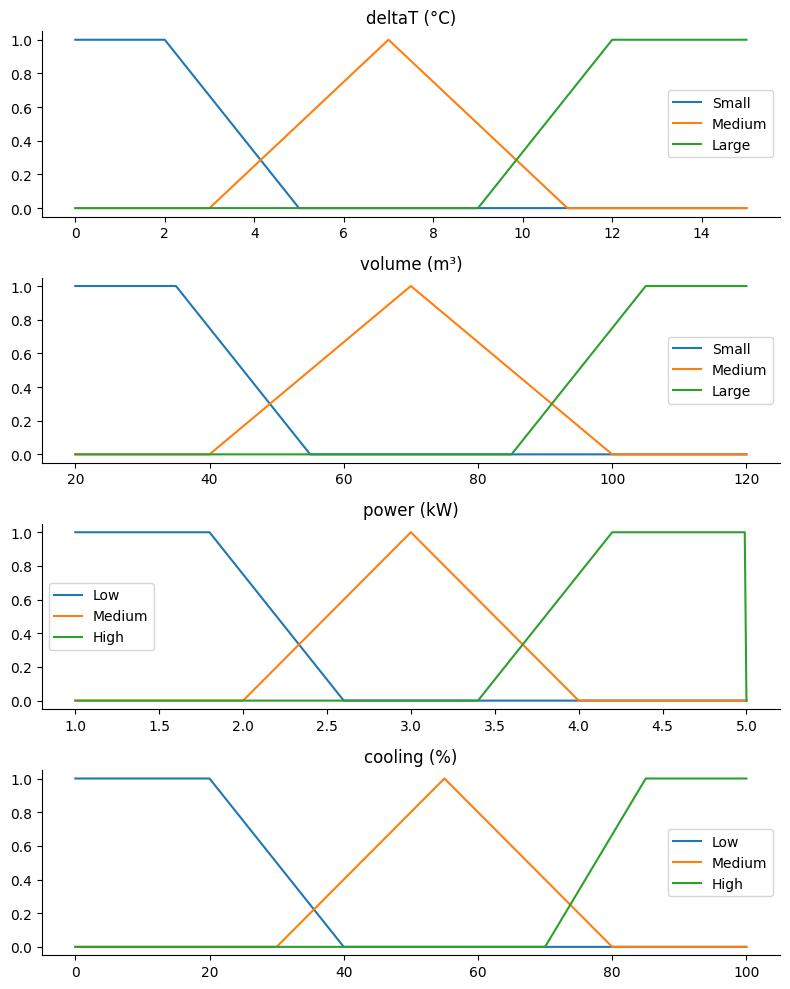

In [ ]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

# 1) Universes (domains)
x_deltaT = np.arange(0, 15.01, 0.1)     # 0..15 °C (step 0.1)
x_volume = np.arange(20, 120.1, 1)      # 20..120 m³ (step 1)
x_power  = np.arange(1.0, 5.01, 0.01)   # 1.0..5.0 kW (step 0.01)
x_cool   = np.arange(0, 100.1, 1)       # 0..100 % (step 1)

# 2) Membership functions (>= 3 per variable)
# deltaT: small / medium / large
dT_small  = fuzz.trapmf(x_deltaT, [0, 0, 2, 5])  # dT_small[i] = μ_small(x_deltaT[i])
dT_medium = fuzz.trimf(x_deltaT, [3, 7, 11])
dT_large  = fuzz.trapmf(x_deltaT, [9, 12, 15, 15])

# volume: small / medium / large
V_small   = fuzz.trapmf(x_volume, [20, 20, 35, 55]) # in outer left edges a should be equal to b
V_medium  = fuzz.trimf(x_volume, [40, 70, 100])
V_large   = fuzz.trapmf(x_volume, [85, 105, 120, 120]) # in outer right edges c should be equal to d

# power: low / medium / high
P_low     = fuzz.trapmf(x_power, [1.0, 1.0, 1.8, 2.6])
P_medium  = fuzz.trimf(x_power, [2.0, 3.0, 4.0])
P_high    = fuzz.trapmf(x_power, [3.4, 4.2, 5.0, 5.0])

# cooling (output): low / medium / high
C_low     = fuzz.trapmf(x_cool, [0, 0, 20, 40])
C_medium  = fuzz.trimf(x_cool, [30, 55, 80])
C_high    = fuzz.trapmf(x_cool, [70, 85, 100, 100])

# 3) Plot membership functions (for report)
fig, axes = plt.subplots(nrows=4, figsize=(8, 10))

# deltaT plot
axes[0].plot(x_deltaT, dT_small,  label='Small')
axes[0].plot(x_deltaT, dT_medium, label='Medium')
axes[0].plot(x_deltaT, dT_large,  label='Large')
axes[0].set_title('deltaT (°C)')
axes[0].legend()

# volume plot
axes[1].plot(x_volume, V_small,  label='Small')
axes[1].plot(x_volume, V_medium, label='Medium')
axes[1].plot(x_volume, V_large,  label='Large')
axes[1].set_title('volume (m³)')
axes[1].legend()

# power plot
axes[2].plot(x_power, P_low,    label='Low')
axes[2].plot(x_power, P_medium, label='Medium')
axes[2].plot(x_power, P_high,   label='High')
axes[2].set_title('power (kW)')
axes[2].legend()

# cooling plot
axes[3].plot(x_cool, C_low,    label='Low')
axes[3].plot(x_cool, C_medium, label='Medium')
axes[3].plot(x_cool, C_high,   label='High')
axes[3].set_title('cooling (%)')
axes[3].legend()

# cosmetics
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()

plt.tight_layout()
plt.show()

## Step 3. Define fuzzy rules describing the operation of the system in question (at least four rules, while the fuzzy knowledge base must be complete)

**Fuzzy rules (7 rules)**

* **R1**: `IF deltaT is small → cooling is low`

* **R2**: `IF deltaT is medium AND volume is small → cooling is medium`

* **R3**: `IF deltaT is medium AND volume is large → cooling is high`

* **R4**: `IF deltaT is large → cooling is high`

* **R5**: `IF power is low AND deltaT is medium_or_large → cooling is high`

* **R6**: `IF power is high AND deltaT is medium AND volume is small → cooling is medium`

* **R7**: `IF deltaT is medium THEN cooling is medium`

Explain ideas:

* the larger the `deltaT` ⇒ need high cooling

* the larger the room ⇒ need higher cooling

* the lower the power ⇒ have to “push” cooling up (because the weak machine needs to run stronger to reach the target)

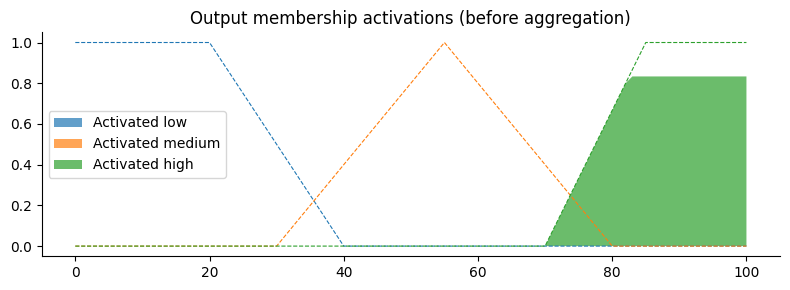

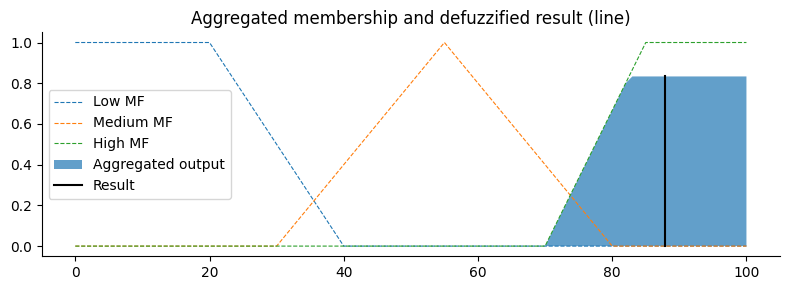


Example input: deltaT_in= 11.50 °C, volume_in= 85.00 m³, power_in= 1.20 kW

Membership degrees:
deltaT: small=0.000, medium=0.000, large=0.833
volume: small=0.000, medium=0.500, large=0.000
power : low=1.000, medium=0.000, high=0.000
Rule strengths: {'r1': np.float64(0.0), 'r2': np.float64(0.0), 'r3': np.float64(0.0), 'r4': np.float64(0.8333333333333334), 'r5': np.float64(0.8333333333333334), 'r6': np.float64(0.0), 'r7': np.float64(0.0)}

Defuzzified cooling = 87.85 %


In [ ]:
# Example inputs
deltaT_in = 11.5     # °C [0..15]
volume_in = 85      # m³ [20..120]
power_in  = 1.2     # kW [1.0..5.0]

# ---------------------------------------
# 1) Fuzzification: degrees of membership
dT_s = fuzz.interp_membership(x_deltaT, dT_small,  deltaT_in)
dT_m = fuzz.interp_membership(x_deltaT, dT_medium, deltaT_in)
dT_l = fuzz.interp_membership(x_deltaT, dT_large,  deltaT_in)

V_s  = fuzz.interp_membership(x_volume, V_small,  volume_in)
V_m  = fuzz.interp_membership(x_volume, V_medium, volume_in)
V_l  = fuzz.interp_membership(x_volume, V_large,  volume_in)

P_l  = fuzz.interp_membership(x_power, P_low,    power_in)
P_m  = fuzz.interp_membership(x_power, P_medium, power_in)
P_h  = fuzz.interp_membership(x_power, P_high,   power_in)

# ---------------------------------------
# 2) Rule strength (AND=min, OR=max)
# R1: deltaT small -> cooling low
r1 = dT_s

# R2: deltaT medium AND volume small -> cooling medium
r2 = np.fmin(dT_m, V_s)

# R3: deltaT medium AND volume large -> cooling high
r3 = np.fmin(dT_m, V_l)

# R4: deltaT large -> cooling high
r4 = dT_l

# R5: power low AND (deltaT medium OR large) -> cooling high
r5 = np.fmin(P_l, np.fmax(dT_m, dT_l))

# R6: power high AND deltaT medium AND volume small -> cooling medium
r6 = np.fmin(P_h, np.fmin(dT_m, V_s))

# R7: deltaT medium -> cooling medium
r7 = dT_m

# ---------------------------------------
# 3) Output activations
# low comes from only rule 1
act_low = np.fmin(r1, C_low)

# medium comes from rules R2 and R6 (take max aggregation between them)
act_medium = np.fmax(
        np.fmin(r2, C_medium),
        np.fmax(np.fmin(r6, C_medium),
                np.fmin(r7, C_medium))
)

# high comes from rules R3, R4, R5 (take max of their clipped outputs)
act_high = np.fmax(np.fmin(r3, C_high),
                     np.fmax(np.fmin(r4, C_high),
                             np.fmin(r5, C_high)))

# ---------------------------------------
# EXTRA: Visualize output activations (before aggregation)
c0 = np.zeros_like(x_cool)
fig, ax = plt.subplots(figsize=(8, 3))
ax.fill_between(x_cool, c0, act_low,    alpha=0.7, label='Activated low')
ax.fill_between(x_cool, c0, act_medium, alpha=0.7, label='Activated medium')
ax.fill_between(x_cool, c0, act_high,   alpha=0.7, label='Activated high')

ax.plot(x_cool, C_low,    linestyle='--', linewidth=0.8)
ax.plot(x_cool, C_medium, linestyle='--', linewidth=0.8)
ax.plot(x_cool, C_high,   linestyle='--', linewidth=0.8)

ax.set_title('Output membership activations (before aggregation)')
ax.legend()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# ---------------------------------------
# 4.1) Aggregation (max)
aggregated = np.fmax(act_low, np.fmax(act_medium, act_high))

# 4.2) Defuzzification (centroid)
cooling_out = fuzz.defuzz(x_cool, aggregated, 'centroid')
cooling_activation = fuzz.interp_membership(x_cool, aggregated, cooling_out)  # for plotting

# ---------------------------------------
# 5) Visualization: aggregated + result line
c0 = np.zeros_like(x_cool)
fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(x_cool, C_low,    linestyle='--', linewidth=0.8, label='Low MF')
ax.plot(x_cool, C_medium, linestyle='--', linewidth=0.8, label='Medium MF')
ax.plot(x_cool, C_high,   linestyle='--', linewidth=0.8, label='High MF')

ax.fill_between(x_cool, c0, aggregated, alpha=0.7, label='Aggregated output')
ax.plot([cooling_out, cooling_out], [0, cooling_activation], 'k', linewidth=1.5, label='Result')

ax.set_title('Aggregated membership and defuzzified result (line)')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\nExample input: deltaT_in={deltaT_in: .2f} °C, volume_in={volume_in: .2f} m³, power_in={power_in: .2f} kW\n")
print("Membership degrees:")
print(f"deltaT: small={dT_s:.3f}, medium={dT_m:.3f}, large={dT_l:.3f}")
print(f"volume: small={V_s:.3f}, medium={V_m:.3f}, large={V_l:.3f}")
print(f"power : low={P_l:.3f}, medium={P_m:.3f}, high={P_h:.3f}")
print("Rule strengths:", {"r1": r1, "r2": r2, "r3": r3, "r4": r4, "r5": r5, "r6": r6, "r7": r7})
print(f"\nDefuzzified cooling = {cooling_out:.2f} %")

We can see that Rule 5 is being strongly activated.

**Remember Fuzzy rules (7 rules)**

* **R1**: `IF deltaT is small → cooling is low`

* **R2**: `IF deltaT is medium AND volume is small → cooling is medium`

* **R3**: `IF deltaT is medium AND volume is large → cooling is high`

* **R4**: `IF deltaT is large → cooling is high`

* **R5**: `IF power is low AND deltaT is medium_or_large → cooling is high`

* **R6**: `IF power is high AND deltaT is medium AND volume is small → cooling is medium`

* **R7**: `IF deltaT is medium THEN cooling is medium`

**Remember I/O domains**:

* `deltaT` [°C] with domain `0..15 `
* `volume` [m³] with domain `20..120`
* `power`  [kW] with domain `1.0..5.0`
* `cooling` [%], domain `0..100`

## Step 4. Simulate the operation of a fuzzy system (at least 5 runs with different input data set randomly)

In [ ]:
rng = np.random.default_rng(42)

def infer_cooling(deltaT_in, volume_in, power_in):
    # fuzzify inputs
    dT_s = fuzz.interp_membership(x_deltaT, dT_small,  deltaT_in)
    dT_m = fuzz.interp_membership(x_deltaT, dT_medium, deltaT_in)
    dT_l = fuzz.interp_membership(x_deltaT, dT_large,  deltaT_in)

    V_s  = fuzz.interp_membership(x_volume, V_small,  volume_in)
    V_l  = fuzz.interp_membership(x_volume, V_large,  volume_in)

    P_l  = fuzz.interp_membership(x_power, P_low,    power_in)
    P_h  = fuzz.interp_membership(x_power, P_high,   power_in)

    dT_m_or_l = np.fmax(dT_m, dT_l)

    # rule strengths (old)
    r1 = dT_s
    r2 = np.fmin(dT_m, V_s)
    r3 = np.fmin(dT_m, V_l)
    r4 = dT_l
    r5 = np.fmin(P_l, dT_m_or_l)
    r6 = np.fmin(P_h, np.fmin(dT_m, V_s))
    r7 = dT_m

    # output activations (clip)
    act_low    = np.fmin(r1, C_low)

    act_medium = np.fmax(
        np.fmin(r2, C_medium),
        np.fmax(np.fmin(r6, C_medium),
                np.fmin(r7, C_medium))
    )

    act_high   = np.fmax(
        np.fmin(r3, C_high),
        np.fmax(np.fmin(r4, C_high),
                np.fmin(r5, C_high))
    )

    # aggregate
    aggregated = np.fmax(act_low, np.fmax(act_medium, act_high))

    # guard against empty area
    if np.sum(aggregated) == 0:
        cooling_out = 0.0
    else:
        cooling_out = fuzz.defuzz(x_cool, aggregated, 'centroid')

    return cooling_out, {"r1": r1, "r2": r2, "r3": r3, "r4": r4, "r5": r5, "r6": r6, "r7": r7}

# run 5 random trials
print("Run | deltaT(°C) | volume(m³) | power(kW) | cooling(%)")
for k in range(1, 6):
    dT = float(rng.uniform(0, 15))
    V  = float(rng.uniform(20, 120))
    P  = float(rng.uniform(1.0, 5.0))

    out, dbg = infer_cooling(dT, V, P)
    print(f"{k:>3} | {dT:>9.2f} | {V:>10.2f} | {P:>9.2f} | {out:>9.2f}")

Run | deltaT(°C) | volume(m³) | power(kW) | cooling(%)
  1 |     11.61 |      63.89 |      4.43 |     87.96
  2 |     10.46 |      29.42 |      4.90 |     76.40
  3 |     11.42 |      98.61 |      1.51 |     87.77
  4 |      6.76 |      57.08 |      4.71 |     55.00
  5 |      9.66 |     102.28 |      2.77 |     67.02


**Remember Fuzzy rules (7 rules)**

* **R1**: `IF deltaT is small → cooling is low`

* **R2**: `IF deltaT is medium AND volume is small → cooling is medium`

* **R3**: `IF deltaT is medium AND volume is large → cooling is high`

* **R4**: `IF deltaT is large → cooling is high`

* **R5**: `IF power is low AND deltaT is medium_or_large → cooling is high`

* **R6**: `IF power is high AND deltaT is medium AND volume is small → cooling is medium`

* **R7**: `IF deltaT is medium THEN cooling is medium`

**Remember I/O domains**:

* `deltaT` [°C] with domain `0..15 `
* `volume` [m³] with domain `20..120`
* `power`  [kW] with domain `1.0..5.0`
* `cooling` [%], domain `0..100`